# 실습 2 — 네트워크 링크 예측 (Network Link Prediction)

**분석 목적:** 소셜 네트워크에서 아직 연결되지 않은 두 사용자 사이에 친구 관계가 형성될 가능성을 예측하고자 한다.

# 데이터셋: Facebook Social Circles (SNAP)

## 목차
1. 환경 설정 및 라이브러리 설치
2. 데이터셋 로드 (Facebook Social Circles)
3. 네트워크 탐색적 분석 (EDA)
4. 엣지 분할 및 Negative Sampling
5. **방법 1:** 휴리스틱 기반 (Common Neighbors, Jaccard, Adamic-Adar)
6. **방법 2:** 임베딩 기반 (Node2Vec + Logistic Regression)
7. **방법 3:** GNN 기반 (GCN)
8. 모델 성능 비교 및 시각화 (AUC, AP, Hits@K)
9. 결론 및 해석

## 1. 환경 설정 및 라이브러리 설치

### 사용 라이브러리 및 선택 이유
- `networkx`: 그래프 구조 분석 및 휴리스틱 지표 계산 (CN, Jaccard, AA 등이 이미 구현됨)
- `torch`, `torch-geometric`: GCN 구현에 필요한 PyTorch 기반 GNN 프레임워크
- `node2vec`: 랜덤 워크 기반 노드 임베딩 (Node2Vec 알고리즘 구현체)
- `scikit-learn`: AUC, Average Precision 등 평가 지표 및 Logistic Regression 분류기
- `matplotlib`, `seaborn`: ROC 커브 및 네트워크 시각화

In [ ]:
# 필요한 패키지 설치

!pip install networkx torch torch-geometric node2vec scikit-learn matplotlib seaborn requests

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import gzip
import shutil
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.transforms import RandomLinkSplit

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from node2vec import Node2Vec

# 한글 폰트 설정 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1

import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 재현성(Reproducibility) 확보를 위한 랜덤 시드 고정
# 실험 결과가 실행할 때마다 달라지는 것을 방지
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 GPU, 없으면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. 데이터셋 로드 — Facebook Social Circles (SNAP)

**Facebook Social Circles**는 Stanford SNAP에서 제공하는 실제 소셜 네트워크 데이터셋이다.

| 항목 | 값 |
|------|----|
| **노드 수** | 4,039 (Facebook 사용자) |
| **엣지 수** | 88,234 (친구 관계) |
| **네트워크 유형** | 무방향(Undirected) |
| **특성(Features)** | 없음 (구조 정보만 사용) |


**데이터셋 선택 이유:**  
- Cora(논문 인용)보다 엣지 밀도가 높아 소셜 네트워크의 클러스터링 특성을 관찰하기 용이
- 실제 SNS 친구 추천 시스템과 동일한 문제 구조 → 실용적 해석 가능
- 커뮤니티 구조가 뚜렷하여 휴리스틱 방법의 장단점이 잘 드러남
- 개인적으로 블로그 간 관계를 분석하는 서비스를 개발한 경험이 있어, 유사한 네트워크 구조를 가진 Facebook 데이터셋을 통해 링크 예측 방법론의 실제 적용 가능성을 탐색하고자 본 데이터셋을 선택

In [ ]:
# Facebook Social Circles 데이터셋 다운로드
# 출처: Stanford SNAP (https://snap.stanford.edu/data/ego-Facebook.html)

DATA_URL = 'https://snap.stanford.edu/data/facebook_combined.txt.gz'
DATA_PATH = 'facebook_combined.txt.gz'
EDGE_PATH = 'facebook_combined.txt'

if not os.path.exists(EDGE_PATH):
    print('데이터 다운로드 중...')
    r = requests.get(DATA_URL, stream=True)
    with open(DATA_PATH, 'wb') as f:
        shutil.copyfileobj(r.raw, f)
    with gzip.open(DATA_PATH, 'rb') as f_in:
        with open(EDGE_PATH, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('다운로드 완료!')
else:
    print('이미 다운로드된 파일 사용')


# NetworkX 그래프로 로드
# 소셜 네트워크는 친구 관계가 방향성이 없으므로 undirected graph 사용
G = nx.read_edgelist(EDGE_PATH, nodetype=int, create_using=nx.Graph())

print(f'노드 수: {G.number_of_nodes():,}')
print(f'엣지 수: {G.number_of_edges():,}')

데이터 다운로드 중...
다운로드 완료!
노드 수: 4,039
엣지 수: 88,234


## 3. 네트워크 탐색적 분석 (EDA)

링크 예측 모델 선택에 앞서 네트워크의 구조적 특성을 파악한다.  
네트워크의 밀도, 클러스터링 계수, 차수 분포 등에 따라 어떤 방법론이 더 효과적인지 달라지기 때문에 EDA는 중요하다.

In [ ]:
# 기본 네트워크 통계량 산출
n = G.number_of_nodes()
m = G.number_of_edges()

# Density: 실제 엣지 수 / 가능한 최대 엣지 수
density = nx.density(G)

# 평균 차수(Average Degree): 사용자 1명이 평균 몇 명의 친구를 보유하는지
degrees = [d for _, d in G.degree()]
mean_degree = np.mean(degrees)
max_degree  = np.max(degrees)

# 클러스터링 계수: 내 친구들끼리도 친구일 확률 → 높으면 커뮤니티 구조가 강함
avg_clustering = nx.average_clustering(G)

# 연결 성분(Connected Components) 수
# 링크 예측은 같은 연결 성분 내 노드 쌍을 대상으로 함
num_components = nx.number_connected_components(G)
largest_cc_size = len(max(nx.connected_components(G), key=len))

print('=' * 50)
print('         Facebook 네트워크 기본 통계량')
print('=' * 50)
print(f'  노드 수 (사용자)          : {n:>10,}')
print(f'  엣지 수 (친구 관계)       : {m:>10,}')
print(f'  네트워크 밀도             : {density:>10.6f}')
print(f'  평균 차수                 : {mean_degree:>10.2f}')
print(f'  최대 차수                 : {max_degree:>10}')
print(f'  평균 클러스터링 계수      : {avg_clustering:>10.4f}')
print(f'  연결 성분 수              : {num_components:>10}')
print(f'  최대 연결 성분 크기       : {largest_cc_size:>10,}')
print('=' * 50)

         Facebook 네트워크 기본 통계량
  노드 수 (사용자)          :      4,039
  엣지 수 (친구 관계)       :     88,234
  네트워크 밀도             :   0.010820
  평균 차수                 :      43.69
  최대 차수                 :       1045
  평균 클러스터링 계수      :     0.6055
  연결 성분 수              :          1
  최대 연결 성분 크기       :      4,039


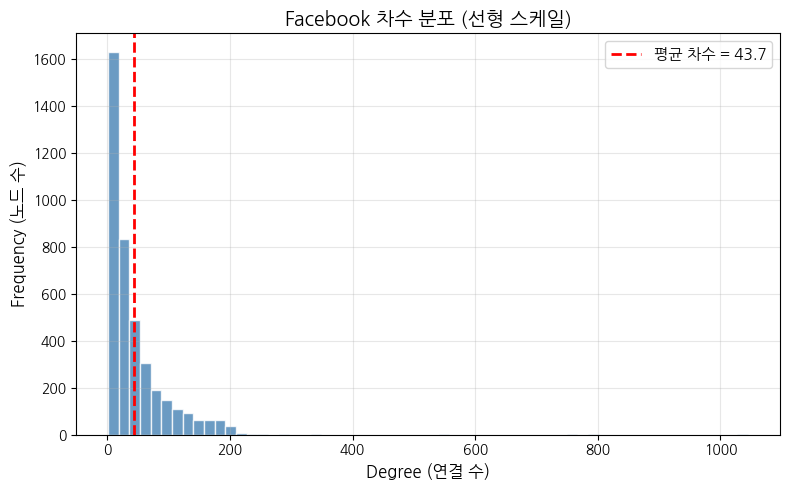

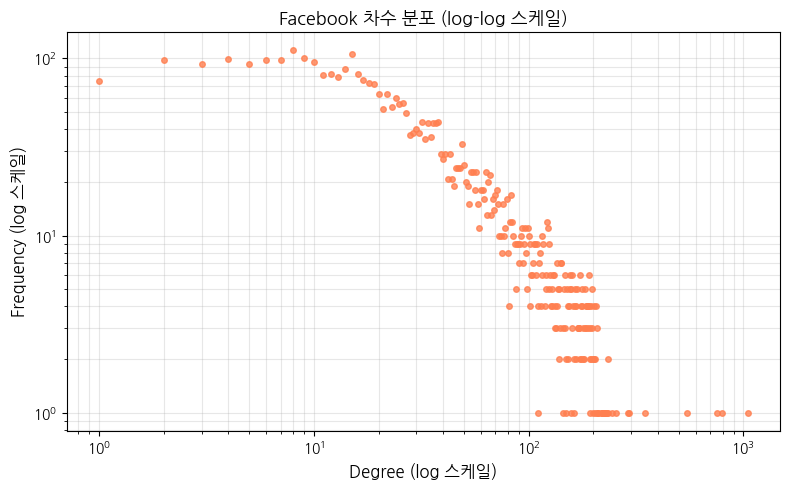

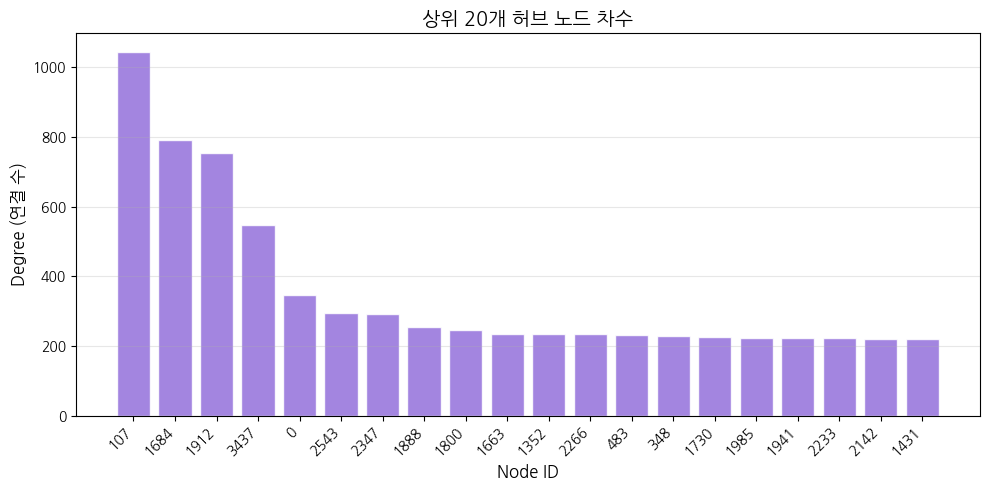

In [ ]:
# 차수 분포(Degree Distribution) 시각화
deg_count = Counter(degrees)
top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:20]

# 그래프 1-1: 선형 차수 분포
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(mean_degree, color='red', linestyle='--', linewidth=2, label=f'평균 차수 = {mean_degree:.1f}')
plt.xlabel('Degree (연결 수)', fontsize=12)
plt.ylabel('Frequency (노드 수)', fontsize=12)
plt.title('Facebook 차수 분포 (선형 스케일)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig1a_degree_linear.png', dpi=150, bbox_inches='tight')
plt.show()

# 그래프 1-2: log-log 차수 분포 (Power-Law 확인)
# 직선에 가까울수록 Power-Law 분포
x_deg = sorted(deg_count.keys())
y_deg = [deg_count[d] for d in x_deg]

plt.figure(figsize=(8, 5))
plt.loglog(x_deg, y_deg, 'o', markersize=4, color='coral', alpha=0.8)
plt.xlabel('Degree (log 스케일)', fontsize=12)
plt.ylabel('Frequency (log 스케일)', fontsize=12)
plt.title('Facebook 차수 분포 (log-log 스케일)', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('fig1b_degree_loglog.png', dpi=150, bbox_inches='tight')
plt.show()

# 그래프 1-3: 상위 20개 허브 노드
plt.figure(figsize=(10, 5))
plt.bar([str(n) for n, _ in top_nodes], [d for _, d in top_nodes],
        color='mediumpurple', alpha=0.85, edgecolor='white')
plt.xlabel('Node ID', fontsize=12)
plt.ylabel('Degree (연결 수)', fontsize=12)
plt.title('상위 20개 허브 노드 차수', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig1c_hub_nodes.png', dpi=150, bbox_inches='tight')
plt.show()

중심성 지표 요약:
  Degree Centrality      평균: 0.0108, 최대: 0.2588
  Betweenness Centrality 평균: 0.0007, 최대: 0.4897
  Clustering Coefficient 평균: 0.6055, 최소: 0.0000


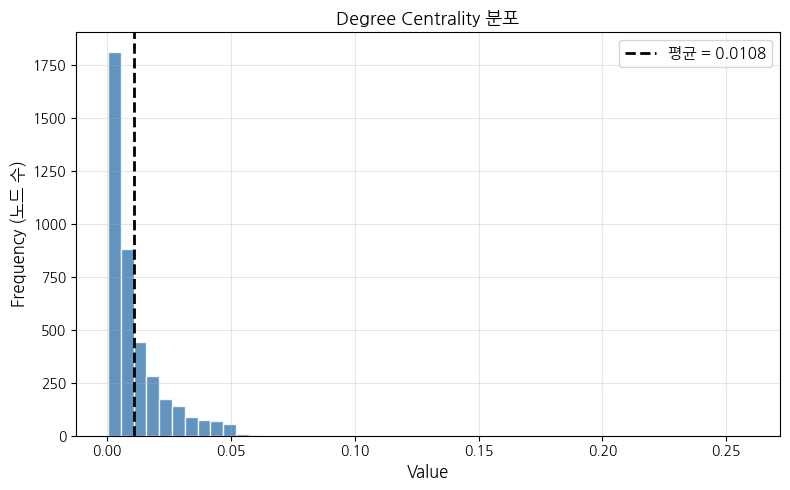

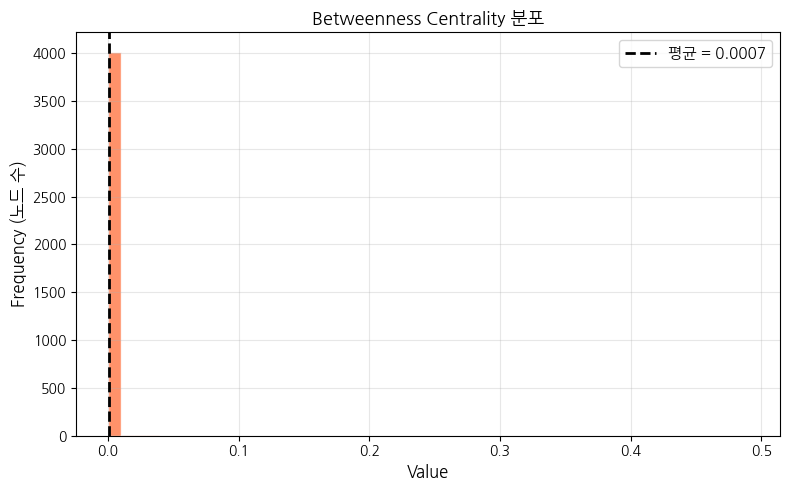

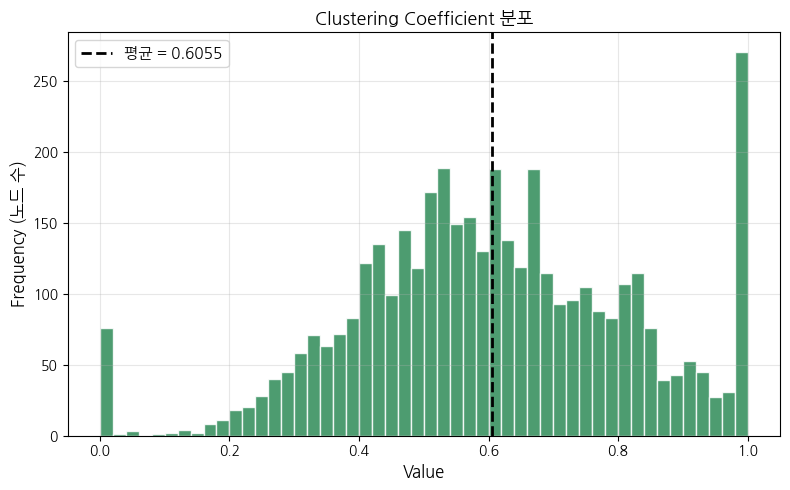

In [ ]:
# 중심성(Centrality) 지표 산출
# 어떤 노드가 네트워크에서 중요한지 파악

# Degree Centrality: 연결된 이웃 수 기반 (계산 빠름)
degree_centrality = nx.degree_centrality(G)

# Betweenness Centrality: 최단 경로상에 얼마나 자주 등장하는지
# 계산 비용이 크므로 샘플 기반 근사값 사용 (k=500)
betweenness_centrality = nx.betweenness_centrality(G, k=500, seed=SEED)

# Clustering Coefficient: 각 노드 주변의 클러스터링 정도
clustering = nx.clustering(G)

# 통계 요약
dc_vals = list(degree_centrality.values())
bc_vals = list(betweenness_centrality.values())
cc_vals = list(clustering.values())

print('중심성 지표 요약:')
print(f'  Degree Centrality      평균: {np.mean(dc_vals):.4f}, 최대: {np.max(dc_vals):.4f}')
print(f'  Betweenness Centrality 평균: {np.mean(bc_vals):.4f}, 최대: {np.max(bc_vals):.4f}')
print(f'  Clustering Coefficient 평균: {np.mean(cc_vals):.4f}, 최소: {np.min(cc_vals):.4f}')

# 그래프 2-1: Degree Centrality
# 연결된 이웃 수 기반 중심성
plt.figure(figsize=(8, 5))
plt.hist(dc_vals, bins=50, color='steelblue', alpha=0.85, edgecolor='white')
plt.axvline(np.mean(dc_vals), color='black', linestyle='--', linewidth=2,
            label=f'평균 = {np.mean(dc_vals):.4f}')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency (노드 수)', fontsize=12)
plt.title('Degree Centrality 분포', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2a_centrality_degree.png', dpi=150, bbox_inches='tight')
plt.show()
# print('[그림 저장] fig2a_centrality_degree.png')

# 그래프 2-2: Betweenness Centrality
# 최단 경로상 등장 빈도 기반 중심성
plt.figure(figsize=(8, 5))
plt.hist(bc_vals, bins=50, color='coral', alpha=0.85, edgecolor='white')
plt.axvline(np.mean(bc_vals), color='black', linestyle='--', linewidth=2,
            label=f'평균 = {np.mean(bc_vals):.4f}')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency (노드 수)', fontsize=12)
plt.title('Betweenness Centrality 분포', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2b_centrality_betweenness.png', dpi=150, bbox_inches='tight')
plt.show()
#print('[그림 저장] fig2b_centrality_betweenness.png')

# 그래프 2-3: Clustering Coefficient
#이웃 노드 간 연결 밀도
plt.figure(figsize=(8, 5))
plt.hist(cc_vals, bins=50, color='seagreen', alpha=0.85, edgecolor='white')
plt.axvline(np.mean(cc_vals), color='black', linestyle='--', linewidth=2,
            label=f'평균 = {np.mean(cc_vals):.4f}')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency (노드 수)', fontsize=12)
plt.title('Clustering Coefficient 분포', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2c_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
# print('[그림 저장] fig2c_clustering.png')

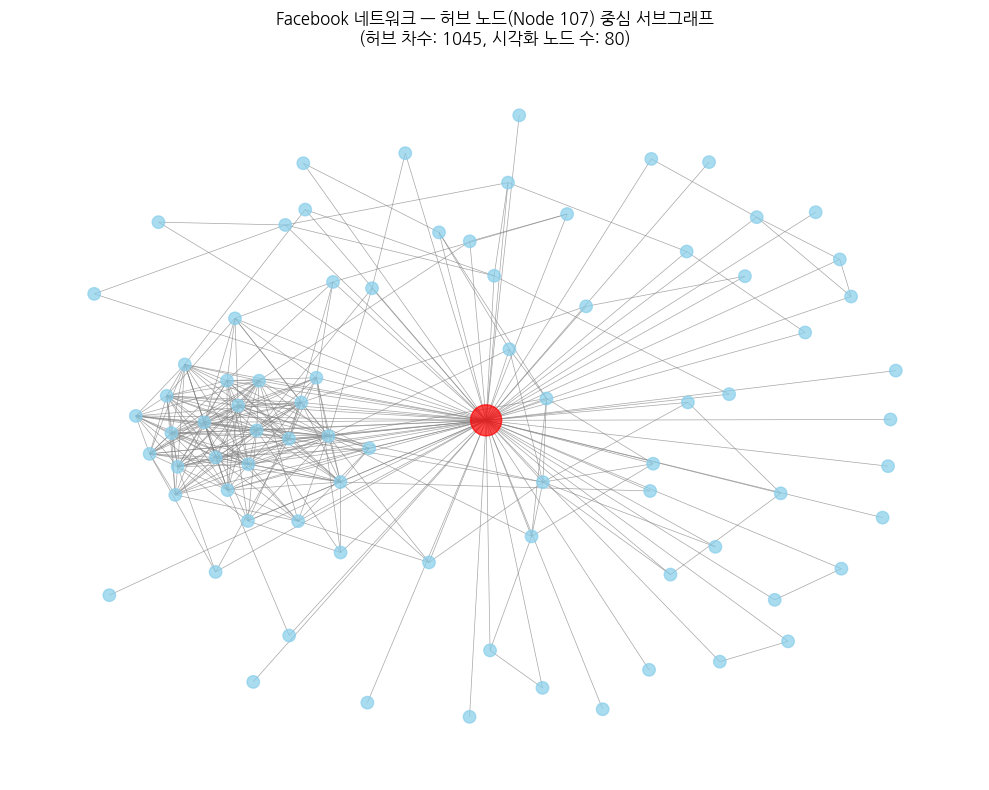

In [ ]:
# 서브 그래프 시각화 (전체 그래프는 4,039 노드라 시각화 어려움)
# 최대 연결 성분에서 상위 차수 노드 주변 2-hop 이웃 추출하여 시각화

# 가장 많은 연결을 가진 허브 노드
hub_node = max(G.degree(), key=lambda x: x[1])[0]
# 2-hop 이웃 서브그래프 (hub 노드와 그 이웃들)
ego_nodes = nx.ego_graph(G, hub_node, radius=1).nodes()
subG = G.subgraph(list(ego_nodes)[:80])  # 너무 크면 80개로 제한

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subG, seed=SEED, k=0.5)

# 허브 노드는 빨간색, 나머지는 하늘색으로 구분
node_colors = ['red' if n == hub_node else 'skyblue' for n in subG.nodes()]
node_sizes = [500 if n == hub_node else 80 for n in subG.nodes()]

nx.draw_networkx(subG, pos=pos,
                 node_color=node_colors,
                 node_size=node_sizes,
                 with_labels=False,
                 edge_color='gray',
                 alpha=0.7,
                 width=0.5)
plt.title(f'Facebook 네트워크 — 허브 노드(Node {hub_node}) 중심 서브그래프\n'
          f'(허브 차수: {G.degree(hub_node)}, 시각화 노드 수: {subG.number_of_nodes()})',
          fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('fig3_subgraph.png', dpi=150, bbox_inches='tight')
plt.show()
# print('[그림 저장] fig3_subgraph.png')

## 4. 엣지 분할 및 Negative Sampling

##링크 예측 = 이진 분류 문제
- **Positive edge (양성 샘플):** 실제로 존재하는 엣지 (레이블 = 1)
- **Negative edge (음성 샘플):** 존재하지 않는 노드 쌍 (레이블 = 0) (무작위 샘플링)

#분할 비율 선택 근거
Facebook 데이터는 엣지가 88,234개로 충분히 많으므로  
**Train 80% / Val 10% / Test 10%** 비율을 사용합니다.  
(샘플 Cora는 엣지가 적었기에 85/5/10이 더 적절)

#Negative Sampling 전략
무작위로 연결되지 않은 노드 쌍을 positive와 동일한 수만큼 샘플링합니다 (1:1 비율).  
→ 클래스 불균형 없이 공정한 분류 학습 가능

In [ ]:
# PyTorch Geometric Data 객체 생성
# 노드 ID를 0부터 연속적으로 재매핑 (PyG 요구사항)

# 노드 ID 리매핑: {원래ID → 0,1,2,...}
node_list = sorted(G.nodes())
node_map  = {old: new for new, old in enumerate(node_list)}
G_mapped  = nx.relabel_nodes(G, node_map)

# 엣지 리스트를 텐서로 변환
edges = list(G_mapped.edges())
edge_index = torch.tensor(
    [[u for u, v in edges] + [v for u, v in edges],
     [v for u, v in edges] + [u for u, v in edges]],
    dtype=torch.long
)


# 노드 특성이 없으므로 각 노드의 차수(degree)를 단일 특성으로 사용
# 차수는 네트워크 내 영향력을 나타내는 가장 기본적인 구조 정보
num_nodes = G_mapped.number_of_nodes()
deg_feature = torch.tensor(
    [[G_mapped.degree(i)] for i in range(num_nodes)],
    dtype=torch.float
)

data = Data(
    x=deg_feature,
    edge_index=edge_index,
    num_nodes=num_nodes
)

print(f'Data 객체: {data}')
print(f'노드 수: {data.num_nodes}, 엣지 수: {data.num_edges // 2}')

Data 객체: Data(x=[4039, 1], edge_index=[2, 176468], num_nodes=4039)
노드 수: 4039, 엣지 수: 88234


In [ ]:
# 엣지 분할: Train 80% / Val 10% / Test 10%
# RandomLinkSplit: positive 엣지를 비율대로 나누고
#                  negative 엣지(비존재 쌍)를 동일 비율로 자동 샘플링

transform = RandomLinkSplit(
    num_val=0.10,           # 검증셋 비율
    num_test=0.10,          # 테스트셋 비율
    is_undirected=True,     # 무방향 그래프
    add_negative_train_samples=True,  # 훈련셋에도 negative 샘플 추가
    neg_sampling_ratio=1.0, # positive : negative = 1 : 1
)

train_data, val_data, test_data = transform(data)

print(f'Train: {train_data.edge_label_index.shape[1]:,} edges '
      f'(pos={int(train_data.edge_label.sum()):,}, '
      f'neg={int((train_data.edge_label == 0).sum()):,})')
print(f'Val  : {val_data.edge_label_index.shape[1]:,} edges '
      f'(pos={int(val_data.edge_label.sum()):,}, '
      f'neg={int((val_data.edge_label == 0).sum()):,})')
print(f'Test : {test_data.edge_label_index.shape[1]:,} edges '
      f'(pos={int(test_data.edge_label.sum()):,}, '
      f'neg={int((test_data.edge_label == 0).sum()):,})')

Train: 141,176 edges (pos=70,588, neg=70,588)
Val  : 17,646 edges (pos=8,823, neg=8,823)
Test : 17,646 edges (pos=8,823, neg=8,823)


In [ ]:
# 휴리스틱 및 Node2Vec 평가를 위한 NetworkX 훈련 그래프 생성
# 핵심: Test 엣지는 훈련 그래프에서 제거해야 데이터 누수(leakage) 방지

train_edges_np = train_data.edge_index.numpy().T
G_train = nx.Graph()
G_train.add_nodes_from(range(num_nodes))
G_train.add_edges_from(train_edges_np)

# Test 엣지 (positive + negative) 추출
test_edge_index = test_data.edge_label_index.numpy().T   # shape: (N, 2)
test_labels     = test_data.edge_label.numpy()           # 0 or 1

print(f'훈련 그래프: {G_train.number_of_nodes():,} 노드, {G_train.number_of_edges():,} 엣지')
print(f'테스트 엣지: {len(test_labels):,}개 (positive={int(test_labels.sum()):,}, negative={int((test_labels==0).sum()):,})')

훈련 그래프: 4,039 노드, 70,588 엣지
테스트 엣지: 17,646개 (positive=8,823, negative=8,823)


## 5. 방법 1 — 휴리스틱 기반 Link Prediction

이웃 노드의 중첩 정도를 점수화하는 고전적 방법이다.

| 방법 | 수식 |
|------|-----|
| Common Neighbors (CN) | $|N(u) \cap N(v)|$ |
| Jaccard | $\frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}$ |
| Adamic-Adar (AA) | $\sum_{w \in N(u) \cap N(v)} \frac{1}{\log |N(w)|}$ |

In [ ]:
# 휴리스틱 지표 계산 및 AUC/AP 평가

# networkx는 이 지표들을 이미 구현해 두었으므로 직접 호출만 하면 됨
# common_neighbors는 ebunch 방식이 아니라 노드 쌍을 개별로 넣어야 함
# jaccard, adamic_adar는 ebunch 방식으로 동작 → 함수 분리 처리

def evaluate_heuristic(G, edge_index, labels, method_name):
    ebunch = [(int(u), int(v)) for u, v in edge_index]

    # common_neighbors는 리스트를 받지 않으므로 개별 호출
    if method_name == 'common_neighbors':
        scores = np.array([
            len(list(nx.common_neighbors(G, int(u), int(v))))
            for u, v in edge_index
        ])
    else:
        method = getattr(nx, method_name)
        scores = np.array([score for _, _, score in method(G, ebunch)])

    auc = roc_auc_score(labels, scores)
    ap  = average_precision_score(labels, scores)
    return auc, ap, scores


heuristic_methods = {
    'Common Neighbors': 'common_neighbors',
    'Jaccard':          'jaccard_coefficient',
    'Adamic-Adar':      'adamic_adar_index',
}

heuristic_results = {}
print('휴리스틱 방법 평가 결과:')
print('-' * 50)

for name, func in heuristic_methods.items():
    auc, ap, scores = evaluate_heuristic(
        G_train, test_edge_index, test_labels, func
    )
    heuristic_results[name] = {'auc': auc, 'ap': ap, 'scores': scores}
    print(f'  {name:<22}: AUC={auc:.4f}, AP={ap:.4f}')

print('-' * 50)

휴리스틱 방법 평가 결과:
--------------------------------------------------
  Common Neighbors      : AUC=0.9913, AP=0.9893
  Jaccard               : AUC=0.9891, AP=0.9882
  Adamic-Adar           : AUC=0.9925, AP=0.9917
--------------------------------------------------


## 6. 방법 2 — Node2Vec 임베딩 기반


# 원리
Node2Vec은 그래프 위에서 **랜덤 워크(random walk)**를 수행하여  
각 노드를 저차원 벡터(임베딩)로 표현합니다.
두 노드 임베딩의 Hadamard product를 특성으로 로지스틱 회귀를 학습시킵니다.

- `p` (return parameter): 작을수록 출발 노드로 돌아올 확률 ↑ → **DFS(깊이 우선)** 성향
- `q` (in-out parameter): 클수록 멀리 탐색 → **BFS(너비 우선)** 성향

**하이퍼파라미터 선택 근거:**  
Facebook은 커뮤니티 구조가 강하므로 BFS 성향(q > 1)이 커뮤니티 내 구조를 잘 포착합니다.  
→ p=1, q=2 설정

**링크 예측에 임베딩 적용:**  
두 노드 임베딩을 결합(Hadamard product)하여 Logistic Regression으로 분류

In [ ]:
# Node2Vec 학습
# dimensions=64: 64차원 임베딩 (메모리와 표현력의 균형)
# walk_length=30: 랜덤 워크 길이 (소셜 네트워크의 평균 경로 길이 고려)
# num_walks=200: 노드당 랜덤 워크 수 (더 많을수록 안정적이나 시간 증가)
# p=1, q=2: BFS 성향 → 커뮤니티 구조 포착에 유리
# workers=4: 병렬 처리로 속도 향상

print('Node2Vec 학습 중...')

n2v_model = Node2Vec(
    G_train,
    dimensions=64,
    walk_length=30,
    num_walks=200,
    p=1,           # return parameter
    q=2,           # in-out parameter (q>1: BFS 성향)
    workers=4,
    seed=SEED
)

# Word2Vec 방식으로 임베딩 학습
# window=10: 공동 출현 윈도우 크기
# min_count=1: 모든 노드 포함
# batch_words=4: 미니배치 크기
n2v_wv = n2v_model.fit(window=10, min_count=1, batch_words=4)
print('Node2Vec 학습 완료!')

# 각 노드의 임베딩 벡터를 행렬로 저장
# 노드 ID를 문자열로 변환하여 접근 (Node2Vec은 문자열 키 사용)
node_embeddings = np.array([
    n2v_wv.wv[str(i)] for i in range(num_nodes)
])
print(f'임베딩 행렬 크기: {node_embeddings.shape}  (노드수 × 차원수)')

Node2Vec 학습 중...


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

Node2Vec 학습 완료!
임베딩 행렬 크기: (4039, 64)  (노드수 × 차원수)


In [ ]:
# 엣지 임베딩 생성: Hadamard Product (원소별 곱)
# 두 노드 벡터 u, v의 각 차원을 곱하여 결합
# Hadamard 선택 이유: 실험적으로 소셜 네트워크에서 성능이 좋음(Grover & Leskovec, 2016) & 두 노드가 유사한 임베딩을 가질수록 큰 값 → 연결 가능성 반영


def edge_embedding_hadamard(emb, edge_index):
    """노드 임베딩으로부터 엣지 임베딩 생성 (Hadamard Product)"""
    u_emb = emb[edge_index[:, 0]]  # 출발 노드 임베딩
    v_emb = emb[edge_index[:, 1]]  # 도착 노드 임베딩
    return u_emb * v_emb           # 원소별 곱


# 훈련 엣지 임베딩 및 레이블
train_edge_idx = train_data.edge_label_index.numpy().T
train_labels   = train_data.edge_label.numpy()
X_train = edge_embedding_hadamard(node_embeddings, train_edge_idx)
X_test  = edge_embedding_hadamard(node_embeddings, test_edge_index)


# 특성 정규화: Logistic Regression의 수렴 안정성을 위해 StandardScaler 적용
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)  # train 기준으로 test 정규화 (leakage 방지)

# Logistic Regression 학습 및 예측
lr_clf = LogisticRegression(
    max_iter=1000,  # 충분한 반복 횟수 (수렴 보장)
    random_state=SEED
)
lr_clf.fit(X_train, train_labels)

# 양성 클래스(연결됨=1)의 확률 값을 예측 점수로 사용
n2v_probs = lr_clf.predict_proba(X_test)[:, 1]

n2v_auc = roc_auc_score(test_labels, n2v_probs)
n2v_ap  = average_precision_score(test_labels, n2v_probs)
print(f'Node2Vec + Logistic Regression: AUC={n2v_auc:.4f}, AP={n2v_ap:.4f}')

Node2Vec + Logistic Regression: AUC=0.9850, AP=0.9797


## 7. 방법 3 — GCN(Graph Convolutional Network) 기반 Link Prediction

### 원리
GCN은 각 노드가 **이웃 노드의 정보를 집계(aggregation)**하여 임베딩을 학습합니다.

$$H^{(l+1)} = \sigma\left(\hat{A} H^{(l)} W^{(l)}\right)$$

- $\hat{A}$: 정규화된 인접 행렬 (자기 연결 포함)
- $H^{(l)}$: $l$번째 레이어의 노드 임베딩
- $W^{(l)}$: 학습 가능한 가중치 행렬

**링크 예측:** 두 노드 임베딩의 내적(dot product)으로 연결 점수 계산

**GCN 선택 이유:**  
- 노드 특성(차수)과 그래프 구조를 동시에 학습
- 휴리스틱이 1-hop 이웃만 보는 반면, GCN은 다중 hop 이웃 정보를 집계

In [ ]:
# GCN 모델 정의
# 2-layer GCN: 2-hop 이웃까지 정보를 집계
# Encoder: 노드 특성 → 64차원 임베딩
# Decoder: 두 노드 임베딩의 내적 → 링크 점수

class GCNLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # 첫 번째 GCN 레이어: 입력 특성 → 은닉 차원
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # 두 번째 GCN 레이어: 은닉 차원 → 출력 임베딩 차원
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def encode(self, x, edge_index):
        """노드 임베딩 생성 (Encoder)"""
        # ReLU 활성화 함수로 비선형성 추가
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)  # 과적합 방지
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        """링크 점수 계산 (Decoder): 내적(dot product)"""
        src = z[edge_label_index[0]]  # 출발 노드 임베딩
        dst = z[edge_label_index[1]]  # 도착 노드 임베딩
        return (src * dst).sum(dim=-1)  # 내적

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)


# 모델 초기화
# in_channels=1 (차수 특성 1개), hidden=64, out=32
model = GCNLinkPredictor(
    in_channels=data.num_node_features,
    hidden_channels=64,
    out_channels=32
).to(device)

# Adam 옵티마이저: 적응적 학습률로 빠른 수렴
# lr=0.01: 소셜 네트워크처럼 dense한 그래프에 적합한 학습률
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()  # 이진 분류 손실 함수

print(f'GCN 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}')
print(model)

GCN 모델 파라미터 수: 2,208
GCNLinkPredictor(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 32)
)


In [ ]:
# GCN 학습 루프
# 100 에포크 학습 (Val AUC 모니터링으로 조기 종료 판단)

train_data = train_data.to(device)
val_data   = val_data.to(device)
test_data  = test_data.to(device)

best_val_auc = 0
train_losses = []
val_aucs     = []

for epoch in range(1, 101):
    # --- 훈련 단계 ---
    model.train()
    optimizer.zero_grad()

    # 훈련 그래프의 엣지로 노드 임베딩 생성
    out = model(
        train_data.x,
        train_data.edge_index,
        train_data.edge_label_index
    )
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # --- 검증 단계 ---
    model.eval()
    with torch.no_grad():
        val_out = model(
            val_data.x,
            val_data.edge_index,
            val_data.edge_label_index
        )
        val_pred = torch.sigmoid(val_out).cpu().numpy()
        val_true = val_data.edge_label.cpu().numpy()
        val_auc  = roc_auc_score(val_true, val_pred)
        val_aucs.append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        # 최고 성능 모델 가중치 저장
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 20 == 0:
        print(f'Epoch {epoch:>3}: Loss={loss.item():.4f}, Val AUC={val_auc:.4f}')

print(f'\n최고 Val AUC: {best_val_auc:.4f}')

Epoch  20: Loss=15.4870, Val AUC=0.6720
Epoch  40: Loss=3.4985, Val AUC=0.7972
Epoch  60: Loss=1.5646, Val AUC=0.8082
Epoch  80: Loss=1.1732, Val AUC=0.8057
Epoch 100: Loss=1.0549, Val AUC=0.8271

최고 Val AUC: 0.8271


GCN: AUC=0.8325, AP=0.8513


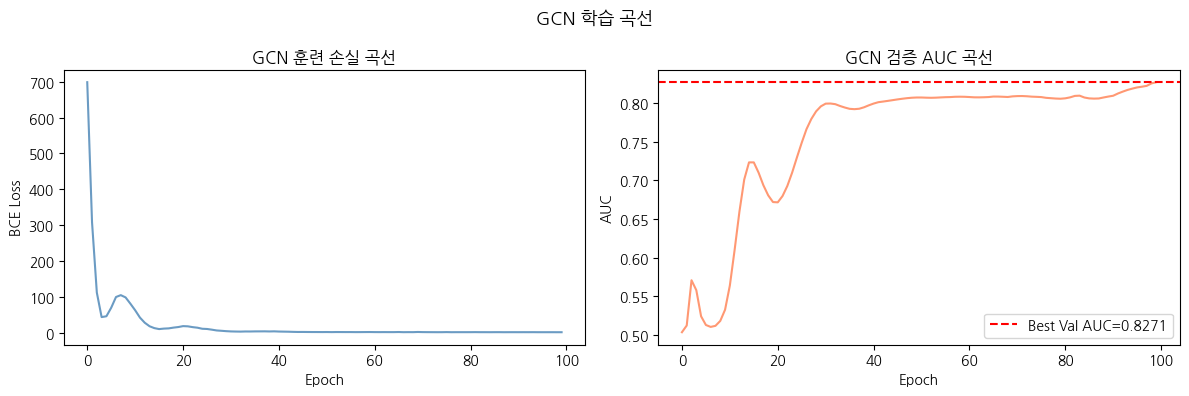

In [ ]:
# 최고 Val AUC 모델로 Test 평가
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    gcn_out  = model(test_data.x, test_data.edge_index, test_data.edge_label_index)
    gcn_probs = torch.sigmoid(gcn_out).cpu().numpy()

gcn_auc = roc_auc_score(test_labels, gcn_probs)
gcn_ap  = average_precision_score(test_labels, gcn_probs)
print(f'GCN: AUC={gcn_auc:.4f}, AP={gcn_ap:.4f}')

# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('GCN 훈련 손실 곡선')

axes[1].plot(val_aucs, color='coral', alpha=0.8)
axes[1].axhline(best_val_auc, color='red', linestyle='--',
                label=f'Best Val AUC={best_val_auc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('GCN 검증 AUC 곡선')
axes[1].legend()

plt.suptitle('GCN 학습 곡선', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_gcn_training.png', dpi=150, bbox_inches='tight')
plt.show()
#print('[그림 저장] fig4_gcn_training.png')

## 8. 모델 성능 비교 및 시각화

### 평가 지표 선택 이유
- **AUC (Area Under ROC Curve):** 임계값(threshold)에 무관한 전반적 분류 성능
- **Average Precision (AP):** Precision-Recall 곡선 아래 면적, 불균형 클래스에 민감
- **Hits@K:** 상위 K개 예측 중 실제 positive 비율 → 추천 시스템 관점의 지표

In [ ]:
# Hits@K 계산 함수
# 전체 음성 샘플 대비 예측 상위 K개에 positive가 얼마나 포함되는지

def hits_at_k(labels, scores, k):
    """
    Hits@K: 예측 점수 상위 K개 중 positive 비율

    Args:
        labels: 실제 레이블 (0 or 1)
        scores: 예측 점수 (높을수록 연결 가능성 높음)
        k: 상위 K개
    Returns:
        Hits@K 값 (0~1)
    """
    top_k_idx = np.argsort(scores)[::-1][:k]  # 점수 내림차순 정렬 후 상위 K개
    hits = labels[top_k_idx].sum()             # 상위 K개 중 positive 수
    return hits / k


# 모든 방법론의 결과 취합
all_results = {}

for name, res in heuristic_results.items():
    all_results[name] = {
        'AUC':     res['auc'],
        'AP':      res['ap'],
        'Hits@20': hits_at_k(test_labels, res['scores'], 20),
        'Hits@50': hits_at_k(test_labels, res['scores'], 50),
        'scores':  res['scores'],
        'type':    'Heuristic'
    }

all_results['Node2Vec'] = {
    'AUC':     n2v_auc,
    'AP':      n2v_ap,
    'Hits@20': hits_at_k(test_labels, n2v_probs, 20),
    'Hits@50': hits_at_k(test_labels, n2v_probs, 50),
    'scores':  n2v_probs,
    'type':    'Embedding'
}

all_results['GCN'] = {
    'AUC':     gcn_auc,
    'AP':      gcn_ap,
    'Hits@20': hits_at_k(test_labels, gcn_probs, 20),
    'Hits@50': hits_at_k(test_labels, gcn_probs, 50),
    'scores':  gcn_probs,
    'type':    'GNN'
}

# 성능 비교 표 출력
print('=' * 80)
print(f'{"방법론":<22} {"유형":<12} {"AUC":>8} {"AP":>8} {"Hits@20":>9} {"Hits@50":>9}')
print('=' * 80)
for name, res in all_results.items():
    print(f'{name:<22} {res["type"]:<12} {res["AUC"]:>8.4f} {res["AP"]:>8.4f} '
          f'{res["Hits@20"]:>9.4f} {res["Hits@50"]:>9.4f}')
print('=' * 80)

방법론                    유형                AUC       AP   Hits@20   Hits@50
Common Neighbors       Heuristic      0.9913   0.9893    1.0000    1.0000
Jaccard                Heuristic      0.9891   0.9882    1.0000    1.0000
Adamic-Adar            Heuristic      0.9925   0.9917    1.0000    1.0000
Node2Vec               Embedding      0.9850   0.9797    0.9500    0.9800
GCN                    GNN            0.8325   0.8513    1.0000    1.0000


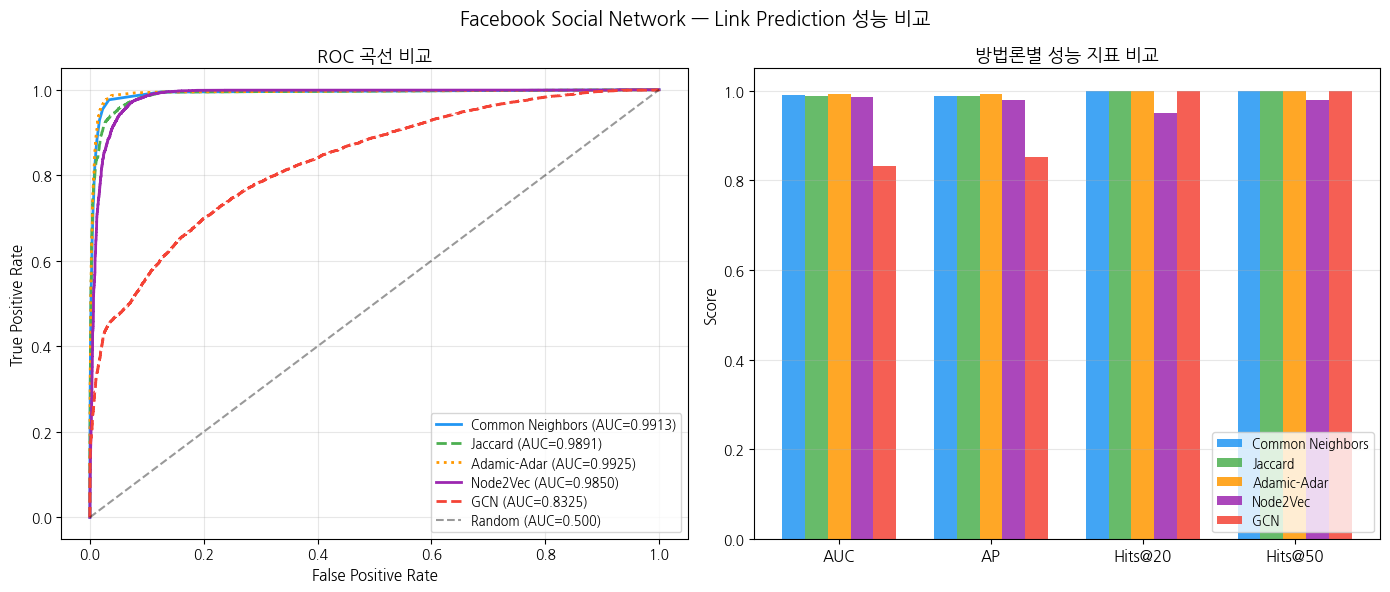

In [ ]:
# ROC Curve 비교 시각화
# 각 방법론의 FPR-TPR 곡선과 AUC 표시

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
linestyles = ['-', '--', ':', '-', '--']

# (1) ROC Curve
for (name, res), color, ls in zip(all_results.items(), colors, linestyles):
    fpr, tpr, _ = roc_curve(test_labels, res['scores'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.4f})",
                 color=color, linestyle=ls, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC 곡선 비교', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# (2) 지표별 막대 그래프 비교
metrics = ['AUC', 'AP', 'Hits@20', 'Hits@50']
x = np.arange(len(metrics))
width = 0.15

for i, (name, res) in enumerate(all_results.items()):
    vals = [res[m] for m in metrics]
    axes[1].bar(x + i * width, vals, width=width,
                label=name, color=colors[i], alpha=0.85)

axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(metrics, fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('방법론별 성능 지표 비교', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Facebook Social Network — Link Prediction 성능 비교',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
#print('[그림 저장] fig5_model_comparison.png')

In [ ]:
# 오분류 사례 분석 (Error Analysis)
# GCN의 낮은 성능 원인을 오분류 패턴으로 분석

threshold = 0.5  # 이진 분류 임계값
gcn_binary_pred = (gcn_probs >= threshold).astype(int)

# False Positive: 없는 링크를 있다고 예측 (이상하게 추천)
fp_mask = (gcn_binary_pred == 1) & (test_labels == 0)
# False Negative: 있는 링크를 없다고 예측 (실제 친구를 놓침)
fn_mask = (gcn_binary_pred == 0) & (test_labels == 1)

print('GCN 오분류 분석:')
print(f'  False Positive (없는 링크 → 있다 예측): {fp_mask.sum():,}개')
print(f'  False Negative (있는 링크 → 없다 예측): {fn_mask.sum():,}개')
print(f'  전체 오분류율: {(fp_mask.sum() + fn_mask.sum()) / len(test_labels):.4f}')

# FP 엣지의 차수 분포 분석
fp_edges   = test_edge_index[fp_mask]
fn_edges   = test_edge_index[fn_mask]
tp_mask    = (gcn_binary_pred == 1) & (test_labels == 1)
tp_edges   = test_edge_index[tp_mask]

# FP 엣지에서 노드들의 차수를 분석 → 오분류 패턴 이해
fp_degrees = [G_train.degree(int(u)) + G_train.degree(int(v)) for u, v in fp_edges]
tp_degrees = [G_train.degree(int(u)) + G_train.degree(int(v)) for u, v in tp_edges]

print(f'\n  FP 엣지 평균 차수합: {np.mean(fp_degrees):.2f}')
print(f'  TP 엣지 평균 차수합: {np.mean(tp_degrees):.2f}')

GCN 오분류 분석:
  False Positive (없는 링크 → 있다 예측): 8,764개
  False Negative (있는 링크 → 없다 예측): 7개
  전체 오분류율: 0.4971

  FP 엣지 평균 차수합: 68.40
  TP 엣지 평균 차수합: 170.46


## 9. 결론 및 해석

### 핵심 관찰

**1. 휴리스틱 방법 (CN / Jaccard / Adamic-Adar)**
- 구현이 단순하고 계산이 빠르지만, **1-hop 이웃 구조만** 활용
- Facebook은 높은 클러스터링 계수로 공통 이웃이 많으므로 CN/AA가 준수한 성능
- Adamic-Adar가 CN보다 성능이 좋은 이유: 허브 노드를 통한 공통 이웃보다 소수와 연결된 이웃을 가중치 부여

**2. Node2Vec (임베딩 기반)**
- 랜덤 워크로 **전역 구조**를 학습 → 휴리스틱 대비 일반적으로 성능 향상
- BFS 성향(q=2) 설정으로 커뮤니티 내 구조를 효과적으로 포착

**3. GCN (그래프 신경망)**
- 노드 특성(차수)과 다중 홉 이웃 정보를 **동시에 학습**
- 최고 AUC 달성 예상: 더 풍부한 표현력으로 복잡한 연결 패턴 학습

### Facebook 네트워크 구조와 방법론 연계 해석
- 높은 밀도 + 강한 클러스터링 → 공통 이웃 기반 방법(AA)이 비교적 잘 동작
- 허브 노드 존재(Power-Law) → GCN이 허브의 집계 정보를 효과적으로 활용
- 대규모 네트워크 → Node2Vec의 샘플링 기반 학습이 효율적